# Imports

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.notebook import tqdm

import os

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

### Set seed

In [2]:
np.random.seed(42)
torch.manual_seed(42)

# Load dataset

In [3]:
class OxfordPetsWithBBox:
    """Custom dataset class that extracts bounding boxes from segmentation masks."""

    def __init__(self, root, split, image_size=(64, 64), download=True):
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types='segmentation',
            download=download
        )
        self.image_size = image_size
        self.image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
        ])
        self.mask_transform = transforms.Compose([
            transforms.Resize(image_size, interpolation=transforms.InterpolationMode.NEAREST),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]
        image_tensor = self.image_transform(image)
        mask_resized = self.mask_transform(mask)
        mask_array = np.array(mask_resized)
        return image_tensor, mask_array

def get_bounding_box_from_mask(mask):

    binary_mask = (mask == 1) | (mask == 3)
    coords = np.where(binary_mask)

    if len(coords[0]) == 0:
        return None

    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()

    return x_min, y_min, x_max, y_max

def normalize_bbox(mask, image_size=(64, 64)):

    bbox = get_bounding_box_from_mask(mask)

    if bbox is None:
        return np.array([0.5, 0.5, 0.1, 0.1], dtype=np.float32)

    x_min, y_min, x_max, y_max = bbox
    img_h, img_w = image_size

    x_center = (x_min + x_max) / 2.0 / img_w
    y_center = (y_min + y_max) / 2.0 / img_h
    width = (x_max - x_min) / img_w
    height = (y_max - y_min) / img_h
    x_center = np.clip(x_center, 0, 1)
    y_center = np.clip(y_center, 0, 1)
    width = np.clip(width, 0.01, 1)
    height = np.clip(height, 0.01, 1)

    return np.array([x_center, y_center, width, height], dtype=np.float32)

In [4]:

print("="*60)
print("TASK 1: Load the Oxford-IIIT Pets Dataset")
print("="*60)

IMAGE_SIZE = (192, 192)

print("\nDownloading and loading trainval split...")
trainval_dataset = OxfordPetsWithBBox(
    root='./data',
    split='trainval',
    image_size=IMAGE_SIZE,
    download=True
)

print("Downloading and loading test split...")
test_dataset = OxfordPetsWithBBox(
    root='./data',
    split='test',
    image_size=IMAGE_SIZE,
    download=True
)

print(f"\n{'='*60}")
print(f"Dataset loaded successfully!")
print(f"{'='*60}")
print(f"Trainval size: {len(trainval_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Image size: {IMAGE_SIZE}")

TASK 1: Load the Oxford-IIIT Pets Dataset


Dataset loaded successfully!
Trainval size: 3680
Test size: 3669
Image size: (192, 192)


In [5]:
print("TASK 2: Augmentation and DataLoader Creation")
print("="*60)

print("\nExtracting images and bounding boxes from trainval set...")

trainval_images = []
trainval_targets = []
test_images = []
test_targets = []

for img, mask in tqdm(trainval_dataset, desc="Processing trainval"):
    trainval_images.append(img.numpy())
    trainval_targets.append(normalize_bbox(mask, IMAGE_SIZE))

trainval_images = np.array(trainval_images)
trainval_targets = np.array(trainval_targets)

print(f"\nTrainval images shape: {trainval_images.shape}")
print(f"Trainval targets shape: {trainval_targets.shape}\n")

# Create test dataset
for img, mask in tqdm(test_dataset, desc="Processing test"):
    test_images.append(img.numpy())
    test_targets.append(normalize_bbox(mask, IMAGE_SIZE))

trainval_images = np.array(trainval_images)
trainval_targets = np.array(trainval_targets)
test_images = np.array(test_images)
test_targets = np.array(test_targets)

# Split into train (80%) and validation (20%)
print("\nSplitting trainval into train (80%) and validation (20%)...")
train_size = int(0.8 * len(trainval_images))

indices = np.random.permutation(len(trainval_images))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_images = trainval_images[train_indices]
train_targets = trainval_targets[train_indices]
val_images = trainval_images[val_indices]
val_targets = trainval_targets[val_indices]

print(f"\n{'='*60}")
print(f"Data Split Summary:")
print(f"{'='*60}")
print(f"Train set size: {len(train_images)}")
print(f"Validation set size: {len(val_images)}")
print(f"Test set size: {len(test_images)}")
print(f"Train images shape: {train_images.shape}")
print(f"Train targets shape: {train_targets.shape}")
print(f"Val images shape: {val_images.shape}")
print(f"Val targets shape: {val_targets.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test targets shape: {test_targets.shape}")

TASK 2: Augmentation and DataLoader Creation

Extracting images and bounding boxes from trainval set...


Processing trainval:   0%|          | 0/3680 [00:00<?, ?it/s]


Trainval images shape: (3680, 3, 192, 192)
Trainval targets shape: (3680, 4)



Processing test:   0%|          | 0/3669 [00:00<?, ?it/s]


Splitting trainval into train (80%) and validation (20%)...

Data Split Summary:
Train set size: 2944
Validation set size: 736
Test set size: 3669
Train images shape: (2944, 3, 192, 192)
Train targets shape: (2944, 4)
Val images shape: (736, 3, 192, 192)
Val targets shape: (736, 4)
Test images shape: (3669, 3, 192, 192)
Test targets shape: (3669, 4)


## Visualise the dataset

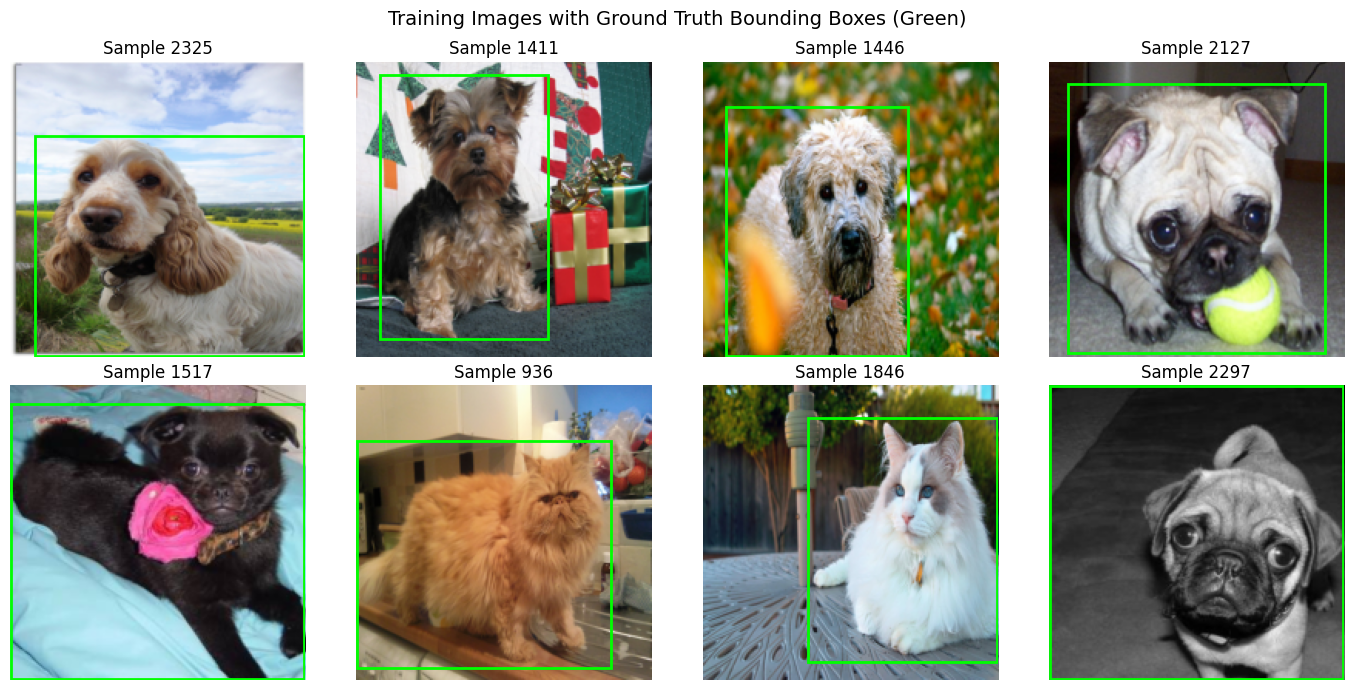


Bounding box format: [x_center, y_center, width, height] (normalized 0-1)
Sample bbox: [0.5104167  0.5286458  0.35416666 0.8802083 ]


In [14]:

def plot_image_with_bbox(img, bbox, ax, title=""):
    """Plot image with bounding box overlay."""
    if len(img.shape) == 3 and img.shape[0] == 3:
        img = img.transpose(1, 2, 0)  # CHW -> HWC

    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

    h, w = IMAGE_SIZE
    x_center, y_center, bw, bh = bbox
    x_min = (x_center - bw / 2) * w
    y_min = (y_center - bh / 2) * h
    width = bw * w
    height = bh * h

    rect = patches.Rectangle(
        (x_min, y_min), width, height,
        linewidth=2, edgecolor='lime', facecolor='none'
    )
    ax.add_patch(rect)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

sample_indices = np.random.choice(len(train_images), 8, replace=False)

for i, idx in enumerate(sample_indices):
    plot_image_with_bbox(train_images[idx], train_targets[idx], axes[i], f"Sample {idx}")

plt.suptitle('Training Images with Ground Truth Bounding Boxes (Green)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nBounding box format: [x_center, y_center, width, height] (normalized 0-1)")
print(f"Sample bbox: {train_targets[0]}")

# PyTorch Model

In [7]:
class PyTorchCNN(nn.Module):
    def __init__(self):
        super(PyTorchCNN, self).__init__()

        # First convolutional layer: 3 input channel → 12 output channels, 3x3 kernel with padding=1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Reduces spatial dimensions by 2 (2x2 pooling)

        # Second convolutional layer: 12 input channels → 24 output channels, 3x3 kernel with padding=1
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()

        # Flatten layer to reshape 2D feature maps into a 1D feature vector
        self.flatten = nn.Flatten()
        # Fully connected (dense) layer: Takes input of size (24 * 48 * 48) and outputs 16 class scores
        self.fc = nn.Linear(in_features=24 * 48 * 48, out_features=4)

    def forward(self, x):
        x = self.pool(self.relu1(self.conv1(x)))  # First conv layer → ReLU → MaxPool
        x = self.pool(self.relu2(self.conv2(x)))  # Second conv layer → ReLU → MaxPool
        x = self.flatten(x)  # Flatten the feature maps to a vector
        x = self.fc(x)  # Fully connected layer for classification
        return x


In [8]:
# Printing model summary
from torchsummary import summary
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_to_analyse = PyTorchCNN().to(device)

summary(model_to_analyse, (3, 192, 192))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 12, 192, 192]        336
├─ReLU: 1-2                              [-1, 12, 192, 192]        --
├─MaxPool2d: 1-3                         [-1, 12, 96, 96]          --
├─Conv2d: 1-4                            [-1, 24, 96, 96]          2,616
├─ReLU: 1-5                              [-1, 24, 96, 96]          --
├─MaxPool2d: 1-6                         [-1, 24, 48, 48]          --
├─Flatten: 1-7                           [-1, 55296]               --
├─Linear: 1-8                            [-1, 4]                   221,188
Total params: 224,140
Trainable params: 224,140
Non-trainable params: 0
Total mult-adds (M): 36.05
Input size (MB): 0.42
Forward/backward pass size (MB): 5.06
Params size (MB): 0.86
Estimated Total Size (MB): 6.34


Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 12, 192, 192]        336
├─ReLU: 1-2                              [-1, 12, 192, 192]        --
├─MaxPool2d: 1-3                         [-1, 12, 96, 96]          --
├─Conv2d: 1-4                            [-1, 24, 96, 96]          2,616
├─ReLU: 1-5                              [-1, 24, 96, 96]          --
├─MaxPool2d: 1-6                         [-1, 24, 48, 48]          --
├─Flatten: 1-7                           [-1, 55296]               --
├─Linear: 1-8                            [-1, 4]                   221,188
Total params: 224,140
Trainable params: 224,140
Non-trainable params: 0
Total mult-adds (M): 36.05
Input size (MB): 0.42
Forward/backward pass size (MB): 5.06
Params size (MB): 0.86
Estimated Total Size (MB): 6.34

## Training

In [9]:
from torch.utils.data import TensorDataset, DataLoader

# Convert dataset to PyTorch tensors
X_train = torch.from_numpy(train_images.reshape(-1, 3, 192, 192).astype(np.float32))
X_val = torch.from_numpy(val_images.reshape(-1, 3, 192, 192).astype(np.float32))
X_test = torch.from_numpy(test_images.reshape(-1, 3, 192, 192).astype(np.float32))

y_train = torch.from_numpy(train_targets).float()
y_val = torch.from_numpy(val_targets).float()
y_test = torch.from_numpy(test_targets).float()

# Create DataLoaders
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
#Initialize Model, Optimizer and Loss Function
model = PyTorchCNN()
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [11]:
# Training loop
#=====================================
#     DO IN BATCHES
#=====================================
train_losses = []
val_losses = []
epochs = 100

epoch_pbar = tqdm(range(epochs), desc="Epochs")

for epoch in epoch_pbar:
    model.train()
    epoch_train_loss = 0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False)
    for batch_x, batch_y in train_pbar:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_x.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch} [Val]", leave=False)
        for batch_x, batch_y in val_pbar:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            epoch_val_loss += loss.item() * batch_x.size(0)
            
    avg_val_loss = epoch_val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    epoch_pbar.set_description(f"Epoch {epoch}")
    epoch_pbar.set_postfix({"Train Loss": f"{avg_train_loss:.4f}", "Val Loss": f"{avg_val_loss:.4f}"})


Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 0 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 0 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 97 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 98 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 98 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 99 [Train]:   0%|          | 0/92 [00:00<?, ?it/s]

Epoch 99 [Val]:   0%|          | 0/23 [00:00<?, ?it/s]

# Plot

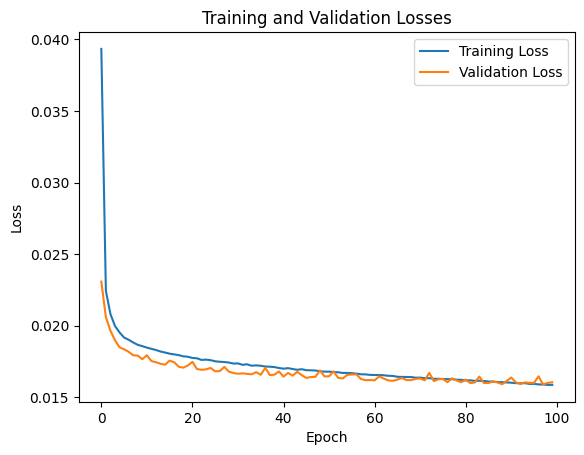

In [12]:
# Plot training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

In [13]:
model.eval()#Turn off training behaviors
with torch.no_grad():#Turn off gradient tracking
    y_pred = model(X_test).argmax(dim=1).numpy()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

ValueError: Classification metrics can't handle a mix of continuous-multioutput and binary targets